# Fast Camera Video Analysis

## Overview

This notebook demonstrates the VEST FAST-camera workflow implemented in `vaft`:
loading and animating raw camera frames, projecting a calibrated pinhole camera
model, overlaying EFIT equilibrium/vessel geometry on real camera frames, and
tracing and projecting magnetic field lines -- all against real, packaged
shot-39915 sample data. Every cell below runs and produces real output; nothing
here is aspirational.

**Methodology reference**: the pinhole-camera calibration and forward-projection
approach follows the VEST FAST-camera diagnostics repository's
`camera_geometry.ipynb` / `CALIBRATION.md` (measured intrinsics from
`CameraParams3.mat`, per-shot pose from `solvePnP` against clicked port
corners). This is a from-scratch reimplementation on vaft's OMAS/IMAS `ods`
data model, not a port -- see the "Known adaptations & limitations" section at
the end for where and why it deliberately diverges from that original
notebook.

**Plotting architecture**: rendering (`vaft.plot`) and ODS interpretation
(`vaft.omas`) are separate layers. `vaft.plot` renderers accept only typed
view models from `vaft.plot.models` -- never an `ods` directly -- and
`vaft.omas.plot_<name>` adapters build those models from an `ods`. Camera
frames use two view models added for this: `Image2D` (a raster image with
optional pixel-space overlays, drawn with `imshow`) and `ImageSequence` (a
frame sequence sharing one color scale, for animation) -- as opposed to
`Field2D`, the existing model for physical `(R, Z)` scalar fields like
equilibrium psi, which renders with `contourf`/`contour` and would be both
far too slow and visually wrong for a dense pixel raster.

In [1]:
from omas import *
import numpy as np
import matplotlib.pyplot as plt
import cv2
import json
import tempfile
from pathlib import Path
from IPython.display import Image as IPyImage

import vaft

## Loading Sample Data

Two independent sample datasets are combined into one `ods` for this notebook:

- `vaft.omas.sample_ods()` -- a real 8-time-slice EFIT `equilibrium` + `wall`
  reconstruction for shot 39915 (times 0.316-0.327 s), packaged at
  `vaft/data/omas/39915.json`.
- `vaft.data.sample_camera_visible_frame_paths(39915)` -- real archived
  FAST-camera frames for the same shot, packaged as PNGs under
  `vaft/data/legacy/`.

These two sources cover **different, only partially overlapping time
windows** (camera: 305.2-331.2 ms; equilibrium: 316-327 ms) -- intentional, and
explained further below.

In [2]:
ods = vaft.omas.sample_ods()
frame_paths = vaft.data.sample_camera_visible_frame_paths(39915)

print(f"Loaded {len(frame_paths)} sample camera frames, "
      f"t = {frame_paths[0][0]*1000:.1f}-{frame_paths[-1][0]*1000:.1f} ms")
print("equilibrium.time (s):", np.asarray(ods["equilibrium.time"]))
print("wall present:", "wall.description_2d" in ods)

Loaded 66 sample camera frames, t = 305.2-331.2 ms
equilibrium.time (s): [0.316 0.317 0.318 0.319 0.32  0.324 0.325 0.327]
wall present: True


## Camera Data Inventory

The FAST camera is a GX-8 CMOS camera; each shot's raw export includes a
`{shot}_bmp.txt` header describing the acquisition (frame rate, sensor size,
trigger timing) and a sequence of `{shot}_{frame:08d}.bmp` grayscale frames.
For archived shot 39915, only the *already-arranged* products survive
(`{shot}_{time_ms}_ms.bmp`, 71 frames spanning 305.2-333.2 ms) -- the raw
sequentially-numbered originals were not retained.

The header for this shot is packaged too; here are its real contents:

In [3]:
header_path = vaft.data.data_path("legacy/39915_bmp.txt")
print(header_path.read_text())

Frame_Rate: 2500
Frame_Size: 1024x1280
Type: GX-8
Version: 1.01
ID: 5
CID: 1955
MCFF_Version: 10001
MCFF_Length: 302140416 Bytes
Media_Type: NET
FrameTime: TRIGGER
TriggerSelect: CENTER
CustomTriggerValue: 0
Trigger Filter: 20.0us
TopFrame: 700
BottomFrame: 850
Frames: 151
Rec_Time: 23/07/04 16:07:17.440922
Scene_No.: 14524
Comment: 
EventFrameList: 
EventTimeList: 
Event AbsTime List:
RecBeginFrame: -1083
RecEndFrame: 1083
ShutterSpeed: 50k(20.0us)
CustomShutterValueNumerator: 397486
CustomShutterValueDenominator: 1000000000
SensorTemp: 49
CameraSN: 1806
Blocks : 1
BlockInfo:1/0 230704160717 440 922 -1083..1083
ESTMode: OFF
EST Filter: 0.0us
TriggerTimeList : 1/0 230704160717 440 922
TriggerFrameList: 0 
SyncStatus: 
VideoFormat: NTSC
Exposure Signal EPO Polarity: NEGATIVE
ExposureTiming: K4 Compatible
DRES Mode: OFF
Pixel Bit Depth: 12bit
Sensor Filter: BW
Rec Trigger Mode: NORMAL
CameraTime: Internal Time
Exposure phase: 0
Black Balance: OFF
Black Balance State: VALID
TimeStamp:  ON

`Frame_Rate: 2500` (Hz) and `Frame_Size: 1024x1280` match what
`vaft.machine_mapping.camera_visible` expects; `TopFrame`/`BottomFrame`/`Frames`
are the fields its frame-to-time linear interpolation is built from (see
`vaft.machine_mapping.camera_visible.frame_time_ms`).

**Sample packaging provenance.** Of the 71 archived frames, not all are
plasma-visible -- some at the start/end of the sequence are near-black. Rather
than package all 71 (or an arbitrary subset), the packaged sample was produced
by *actually running* vaft's own dark-frame-rejection logic --
`vaft.machine_mapping.camera_visible.find_valid_frame_interval` /
`is_near_black` (the same functions `camera_visible()` runs on a raw numbered
sequence; see `test/test_camera_visible_mapping.py`) -- on the 71 archived
frames with its default parameters (`threshold=35, percentage=0.98,
buffer_frames=2`). That returned a 66-frame valid interval (305.2-331.2 ms),
which is exactly what's packaged here and loaded above.

## Building the `camera_visible` ODS Branch

`vaft.machine_mapping.camera_visible.camera_visible()` is the function that
runs the *full* raw-sequence pipeline (dark-frame rejection, frame-to-time
conversion, ODS population) from `{shot}_{frame:08d}.bmp` originals. Since
those raw originals aren't available for this archived shot, this notebook
instead calls its two lower-level building blocks directly --
`vfit_camera_visible_static`/`vfit_camera_visible_dynamic` -- on the already
time-labeled sample frames loaded above.

In [4]:
from vaft.machine_mapping.camera_visible import (
    vfit_camera_visible_static,
    vfit_camera_visible_dynamic,
)

images = [cv2.imread(str(path), cv2.IMREAD_GRAYSCALE) for _, path in frame_paths]
times_s = [t for t, _ in frame_paths]
lines_n, columns_n = images[0].shape

vfit_camera_visible_static(
    ods,
    lines_n=lines_n,
    columns_n=columns_n,
    channel_name="Fast Camera",
    source=str(header_path),
    comment_extra=(
        "VAFT demo notebook sample data: 66-frame valid interval "
        "(305.2-331.2 ms) packaged from archived shot 39915 frames."
    ),
)
vfit_camera_visible_dynamic(ods, images=images, times_s=times_s)

n_frames = len(ods["camera_visible.channel.0.detector.0.frame"])
print(f"camera_visible.channel.0.detector.0.frame now has {n_frames} frames")
print(f"frame shape: {lines_n} rows x {columns_n} columns")

camera_visible.channel.0.detector.0.frame now has 66 frames
frame shape: 1280 rows x 1024 columns


## Static Frame Plotting

`vaft.plot` renders from typed view models only (never an `ods` directly);
`vaft.omas.plot_camera_visible_image_frame` is the adapter that builds an
`Image2D` view model from `ods` and renders it with
`vaft.plot.camera_visible_image_frame`. It draws with `imshow` (raw digital
levels, uncalibrated) using `origin="upper"` so row 0 is the top of the
sensor, matching the row-major `(lines_n, columns_n)` array layout.

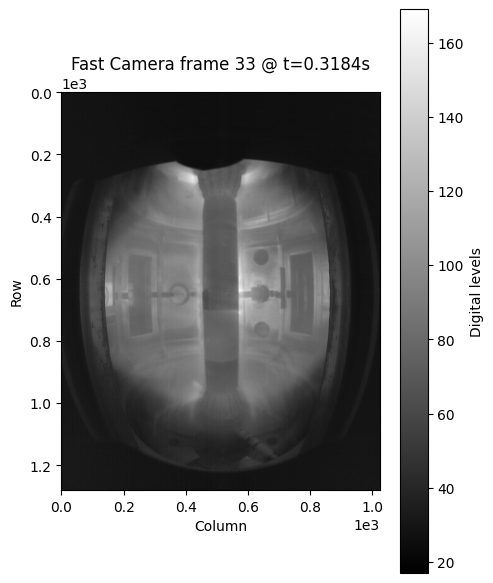

In [5]:
mid_index = len(images) // 2
fig, ax = vaft.omas.plot_camera_visible_image_frame(ods, frame_index=mid_index)

## Animation

`vaft.omas.plot_camera_visible_animation_frames` builds an `ImageSequence`
view model (a frame sequence sharing one color scale, computed once across
the selected frames so intensity stays directly comparable) and renders it
with `vaft.plot.camera_visible_animation_frames`. Here it renders the full
66-frame sample sequence to an animated GIF.

2026-08-24 15:56:58,369 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


Saved 66-frame animation to /var/folders/f2/qq8zn4s97bn_3nr5j_yxcb4h0000gn/T/vest_39915_camera_visible.gif (3.57 MB)


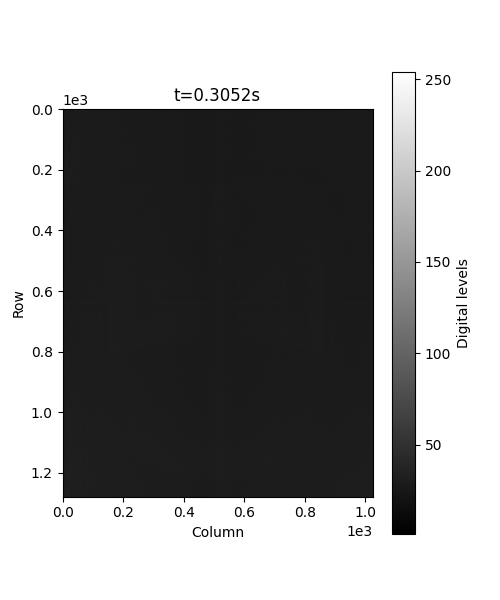

In [6]:
gif_path = Path(tempfile.gettempdir()) / "vest_39915_camera_visible.gif"
fig, ax, anim = vaft.omas.plot_camera_visible_animation_frames(
    ods, save_path=gif_path, fps=8, show=False,
)
plt.close(fig)
print(f"Saved {len(images)}-frame animation to {gif_path} ({gif_path.stat().st_size/1e6:.2f} MB)")
IPyImage(filename=str(gif_path))

## Camera Calibration & Geometry

Projecting 3D machine geometry into camera pixel space uses a standard OpenCV
pinhole model with Brown-Conrady radial/tangential distortion:

1. **Intrinsics** (`fx, fy, cx, cy` + distortion `k1, k2, k3, p1, p2`) --
   measured from `CameraParams3.mat` (a MATLAB `cameraParameters` object,
   parsed via fixed-offset byte extraction from its MCOS binary blob; see the
   diagnostics repo's `CALIBRATION.md`). Shared across shots (same physical
   camera/lens).
2. **Pose** (`rvec, tvec`) -- solved per shot via `cv2.solvePnP` against 16
   clicked vessel-port-corner correspondences. vaft packages this as
   `vaft/data/geometry/camera_visible/pose_{shot}.json` for the three
   calibrated shots (34764, 39915, 47518).

A key finding from validating this pipeline: regardless of which pixel
convention (`distorted` vs `undistorted_full`) was used to *solve* for a
shot's pose, the recovered `(rvec, tvec)` is the true physical camera
attitude, so projecting onto the *original* (raw, distorted) camera frame uses
the exact same formula for every calibrated shot -- no per-shot branching.

World points use a fixed convention: `(X, Y, Z)_cm = (R*cos(phi), R*sin(phi),
Z)_m * 100` (`R, Z` in meters, `phi` in radians, world points in centimeters).

`vaft.process.camera_geometry.project_points` also masks out points at an
extreme angle from the optical axis (normalized image-plane radius
`>= max_normalized_radius`, default 1.3), not just points behind the camera --
this fixes a real bug found while validating this pipeline: outside the
angular range the distortion polynomial was fit over, it can turn
non-monotonic and map a point to a wildly wrong pixel location instead of
smoothly extrapolating off-frame.

In [7]:
intrinsics = json.loads(vaft.data.data_path("geometry/camera_visible/intrinsics.json").read_text())
pose = json.loads(vaft.data.data_path("geometry/camera_visible/pose_39915.json").read_text())

camera_matrix = np.array([
    [intrinsics["fx"], 0.0, intrinsics["cx"]],
    [0.0, intrinsics["fy"], intrinsics["cy"]],
    [0.0, 0.0, 1.0],
])
dist_coeffs = np.array([intrinsics["k1"], intrinsics["k2"], intrinsics["p1"], intrinsics["p2"], intrinsics["k3"]])
rvec = np.array(pose["rvec"])
tvec = np.array(pose["tvec"])

print("camera matrix K:\n", camera_matrix)
print("distortion coeffs [k1,k2,p1,p2,k3]:", dist_coeffs)
print("pose rvec (Rodrigues):", rvec)
print("pose tvec (cm):", tvec)
print(f"packaged calibration reprojection error: mean={pose['reproj_mean_px']:.2f}px, max={pose['reproj_max_px']:.2f}px")

camera matrix K:
 [[555.76    0.    519.476]
 [  0.    555.463 644.235]
 [  0.      0.      1.   ]]
distortion coeffs [k1,k2,p1,p2,k3]: [-0.33    0.1427  0.      0.     -0.0326]
pose rvec (Rodrigues): [ 1.55620515 -0.02930651  0.00283646]
pose tvec (cm): [ 0.4411896  -0.17028539 96.61258994]
packaged calibration reprojection error: mean=3.49px, max=5.51px


### Worked example: projecting real geometry

To make the coordinate transform concrete, project the same analytically-known
vessel-port-corner world points the calibration itself was solved from, and
compare against the packaged reprojection error above.

In [8]:
from vaft.process.camera_geometry import project_points, sweep_toroidal

def compute_port_world_points():
    # VEST port-corner geometry (cm), matching the calibration notebook's own formula.
    Zport_up = 0.57 - 0.2355
    Zport_down = Zport_up - 0.692
    Rport = 0.803
    angle_port_width = np.arccos(1 - 0.24**2 / (2 * Rport**2))

    def port_corners(base_angle):
        a0, a1, ac = base_angle, base_angle + angle_port_width, base_angle + angle_port_width / 2
        Xl, Yl = Rport * np.cos(a0), Rport * np.sin(a0)
        Xr, Yr = Rport * np.cos(a1), Rport * np.sin(a1)
        Xc, Yc = Rport * np.cos(ac), Rport * np.sin(ac)
        Zm = (Zport_up + Zport_down) / 2
        return np.array([
            [Xr, Yr, Zport_up], [Xr, Yr, Zport_down], [Xl, Yl, Zport_down], [Xl, Yl, Zport_up],
            [Xr, Yr, Zm], [Xc, Yc, Zport_down], [Xl, Yl, Zm], [Xc, Yc, Zport_up],
        ]) * 100.0

    a1 = np.deg2rad(30.0) - angle_port_width / 2
    a2 = a1 + np.deg2rad(120.0)
    return np.vstack([port_corners(a1), port_corners(a2)])

world_pts = compute_port_world_points()
uv, valid = project_points(world_pts, rvec, tvec, camera_matrix, dist_coeffs)
print(f"Projected {int(valid.sum())}/{len(valid)} port-corner points onto the image.")
print(f"Pixel range: u=[{uv[:,0].min():.0f}, {uv[:,0].max():.0f}]  v=[{uv[:,1].min():.0f}, {uv[:,1].max():.0f}]")

Projected 16/16 port-corner points onto the image.
Pixel range: u=[219, 813]  v=[512, 791]


`sweep_toroidal` extends a single point (in this case a poloidal wall
cross-section) into a swept 3D point cloud through a range of toroidal
angles, which `project_points` then projects all at once -- the same
primitive `compute_camera_visible_efit_overlay` uses internally for the
wall/LCFS/flux-surface overlay in the next section. Here it's used directly,
by hand, to project the real wall geometry onto a real frame:

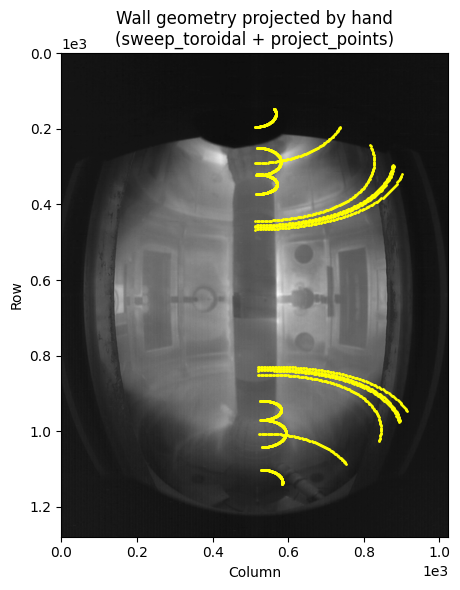

In [9]:
wall_r = np.asarray(ods["wall.description_2d.0.limiter.unit.0.outline.r"])
wall_z = np.asarray(ods["wall.description_2d.0.limiter.unit.0.outline.z"])
theta = np.deg2rad(np.linspace(-90.0, 90.0, 181))
wall_world_cm = sweep_toroidal(wall_r, wall_z, theta)
wall_uv, wall_valid = project_points(wall_world_cm, rvec, tvec, camera_matrix, dist_coeffs)

fig, ax = plt.subplots(figsize=(5.0, 6.0))
ax.imshow(images[mid_index], cmap="gray", origin="upper", aspect="equal")
ax.scatter(wall_uv[wall_valid, 0], wall_uv[wall_valid, 1], s=1, color="yellow")
ax.set_xlabel("Column"); ax.set_ylabel("Row")
ax.set_title("Wall geometry projected by hand\n(sweep_toroidal + project_points)")
fig.tight_layout()
plt.show()

## Equilibrium and Vessel-Geometry Overlay

`vaft.omas.plot_camera_visible_image_efit_overlay` combines the projection
above with equilibrium/wall data read directly from the `ods`, building an
`Image2D` whose `overlays` are pixel-space `GeometryLayer`s (wall/LCFS/
magnetic-axis/flux-surfaces), rendered by `vaft.plot.camera_visible_image_efit_overlay`:

- **Wall** -- `wall.description_2d.0.limiter.unit.0.outline` (from GEQDSK
  `RLIM`/`ZLIM`).
- **LCFS** -- `equilibrium.time_slice[:].boundary.outline`.
- **Magnetic axis** -- `equilibrium.time_slice[:].global_quantities.magnetic_axis`.
- **Flux surfaces** -- iso-`psi_norm` contours extracted from the 2D psi grid
  (`vaft.process.equilibrium.extract_flux_surface_contours`). This is a
  deliberate adaptation from the original diagnostics notebook, which used a
  separately pre-fit 50-surface `.mat` product that isn't part of the ODS data
  model -- the LCFS itself (level 1.0) is directly comparable, other levels
  are ODS-derived rather than the original notebook's exact surfaces.

The camera-frame time and equilibrium time slice are matched *independently*
by nearest-time lookup, so this only produces a meaningful overlay for camera
frames within/near the equilibrium's 316-327 ms window -- frames outside that
window (like the animation above) still plot fine on their own, they simply
have no equilibrium reconstruction to overlay.

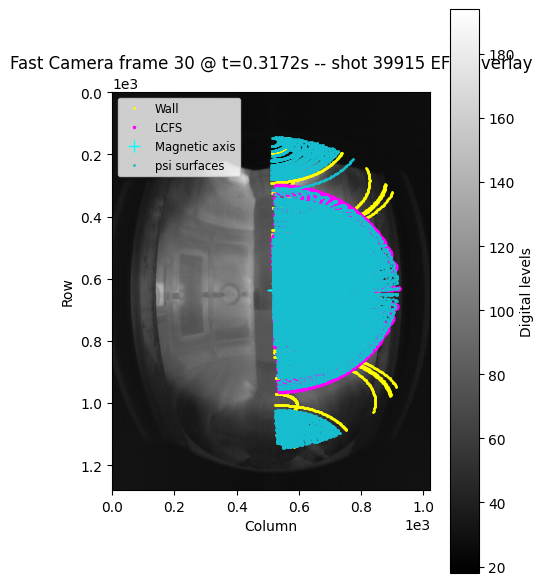

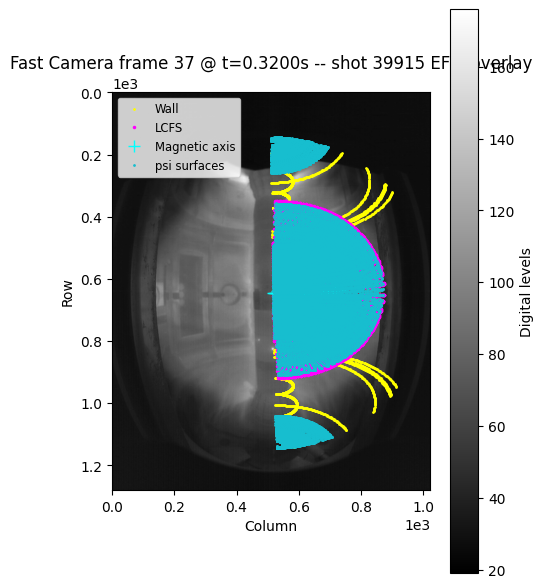

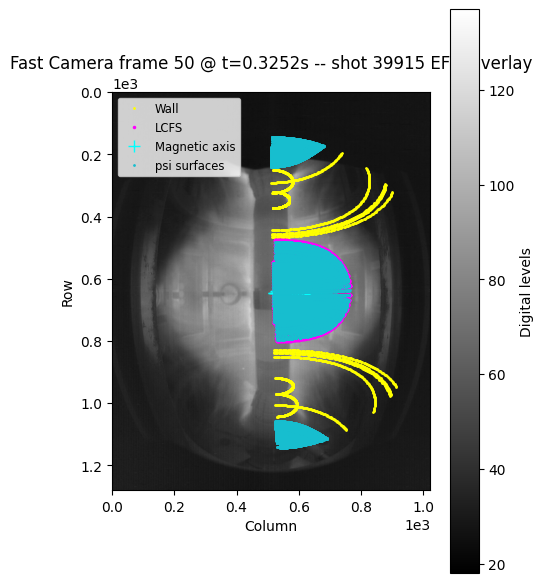

In [10]:
frame_times_ms = np.array([t * 1000.0 for t, _ in frame_paths])
demo_times_ms = [317.2, 320.0, 325.2]

for target_ms in demo_times_ms:
    idx = int(np.argmin(np.abs(frame_times_ms - target_ms)))
    vaft.omas.plot_camera_visible_image_efit_overlay(
        ods, shot=39915, frame_index=idx,
        flux_surface_levels=(0.25, 0.5, 0.75, 0.95),
    )

## Magnetic Field-Line Tracing and Projection

A magnetic field line is traced from a starting point `(R0, Z0, phi0)` by
integrating

$$\frac{dR}{d\phi} = \frac{R\,B_R}{B_\phi}, \qquad \frac{dZ}{d\phi} = \frac{R\,B_Z}{B_\phi}$$

using the equilibrium's own field, with the standard EFIT Weber/rad psi
convention: $B_R = -\frac{1}{R}\frac{\partial\psi}{\partial Z}$,
$B_Z = \frac{1}{R}\frac{\partial\psi}{\partial R}$, $B_\phi = F(\psi)/R$.
Integration is fixed-step classic 4th-order Runge-Kutta (RK4) in the toroidal
angle $\phi$; the trace terminates when it crosses the vessel wall or exceeds
a requested maximum arc length.

**Limitation**: $F(\psi)$ is only defined over the confined region
(`profiles_1d.psi`/`profiles_1d.f`, axis to boundary); outside the LCFS it is
clipped to its boundary value rather than modeling a true scrape-off-layer
vacuum field -- an approximation for field lines that leave the confined
region, not a full edge/SOL field model.

In [11]:
target_ms = 320.0
eq_idx = int(np.argmin(np.abs(np.asarray(ods["equilibrium.time"]) * 1000.0 - target_ms)))
ts = ods[f"equilibrium.time_slice.{eq_idx}"]
Rmag = float(ts["global_quantities.magnetic_axis.r"])
Zmag = float(ts["global_quantities.magnetic_axis.z"])
lcfs_r = np.asarray(ts["boundary.outline.r"])
print(f"Using equilibrium.time_slice.{eq_idx} (t={float(ods['equilibrium.time'][eq_idx])*1000:.0f} ms), "
      f"Rmag={Rmag:.3f} m, Zmag={Zmag:.3f} m, LCFS R range [{lcfs_r.min():.3f}, {lcfs_r.max():.3f}] m")

R0 = 0.5 * (Rmag + lcfs_r.max())  # roughly midway between axis and outboard LCFS
Z0 = Zmag
print(f"Field-line start point: R0={R0:.3f} m, Z0={Z0:.3f} m, phi0=0 rad")

Using equilibrium.time_slice.4 (t=320 ms), Rmag=0.364 m, Zmag=0.000 m, LCFS R range [0.104, 0.576] m
Field-line start point: R0=0.470 m, Z0=0.000 m, phi0=0 rad


In [12]:
trace = vaft.omas.process_wrapper.compute_field_line_trace(
    ods, r0=R0, z0=Z0, phi0=0.0,
    time_index=eq_idx, dphi_deg=0.5, max_length_m=10.0,
    direction="forward", use_wall_boundary=True,
)
print(f"termination: {trace['termination_reason']}, "
      f"{trace['phi'].size} steps, "
      f"arc length {trace['arc_length_m'][-1]:.2f} m, "
      f"toroidal span {np.degrees(trace['phi'][-1] - trace['phi'][0]):.1f} deg")

termination: max_length_m, 2305 steps, arc length 10.00 m, toroidal span 1152.0 deg


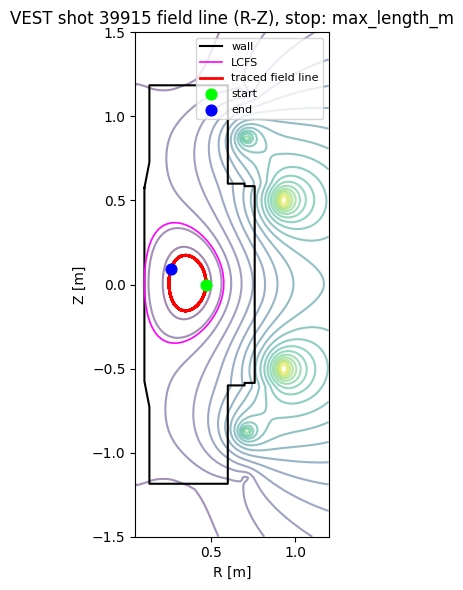

In [13]:
R_grid = np.asarray(ts["profiles_2d.0.grid.dim1"])
Z_grid = np.asarray(ts["profiles_2d.0.grid.dim2"])
# profiles_2d.0.psi is written as shape (len(R), len(Z)) by vaft.data.eqdsk.to_omas
# (PSIRZ.reshape(nw, nh)). A shape-equality guess at whether to transpose is
# genuinely ambiguous -- and silently wrong -- for a square grid (this sample
# is 129x129, EFIT's common default): assert the known-correct orientation
# instead of guessing (see vaft.omas.process_wrapper._read_psi_grid).
psi_grid = np.asarray(ts["profiles_2d.0.psi"])
assert psi_grid.shape == (R_grid.size, Z_grid.size), psi_grid.shape
Rm, Zm = np.meshgrid(R_grid, Z_grid, indexing="ij")
wall_r = np.asarray(ods["wall.description_2d.0.limiter.unit.0.outline.r"])
wall_z = np.asarray(ods["wall.description_2d.0.limiter.unit.0.outline.z"])

fig, ax = plt.subplots(figsize=(5.5, 6.0))
ax.contour(Rm, Zm, psi_grid, levels=20, cmap="viridis", alpha=0.5)
ax.plot(np.append(wall_r, wall_r[0]), np.append(wall_z, wall_z[0]), color="black", lw=1.5, label="wall")
ax.plot(lcfs_r, np.asarray(ts["boundary.outline.z"]), color="magenta", lw=1.2, label="LCFS")
ax.plot(trace["R"], trace["Z"], color="red", lw=2, label="traced field line")
ax.scatter([R0], [Z0], color="lime", s=60, zorder=5, label="start")
ax.scatter([trace["R"][-1]], [trace["Z"][-1]], color="blue", s=60, zorder=5, label="end")
ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.set_aspect("equal")
ax.set_title(f"VEST shot 39915 field line (R-Z), stop: {trace['termination_reason']}")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

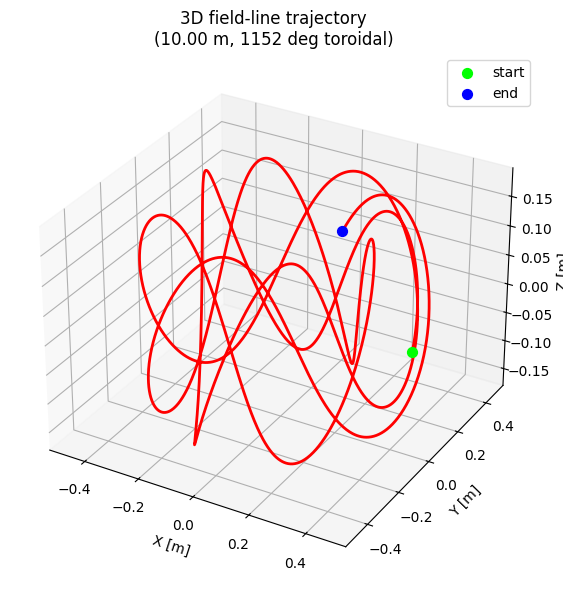

In [14]:
X = trace["R"] * np.cos(trace["phi"])
Y = trace["R"] * np.sin(trace["phi"])

fig = plt.figure(figsize=(6.5, 6.0))
ax3d = fig.add_subplot(111, projection="3d")
ax3d.plot(X, Y, trace["Z"], color="red", lw=2)
ax3d.scatter([X[0]], [Y[0]], [trace["Z"][0]], color="lime", s=50, label="start")
ax3d.scatter([X[-1]], [Y[-1]], [trace["Z"][-1]], color="blue", s=50, label="end")
ax3d.set_xlabel("X [m]"); ax3d.set_ylabel("Y [m]"); ax3d.set_zlabel("Z [m]")
ax3d.set_title(f"3D field-line trajectory\n({trace['arc_length_m'][-1]:.2f} m, "
                f"{np.degrees(trace['phi'][-1]-trace['phi'][0]):.0f} deg toroidal)")
ax3d.legend()
fig.tight_layout()
plt.show()

Finally, project this same traced field line onto the camera frame nearest
`t=320 ms`, together with the wall/LCFS/magnetic-axis overlay for context:

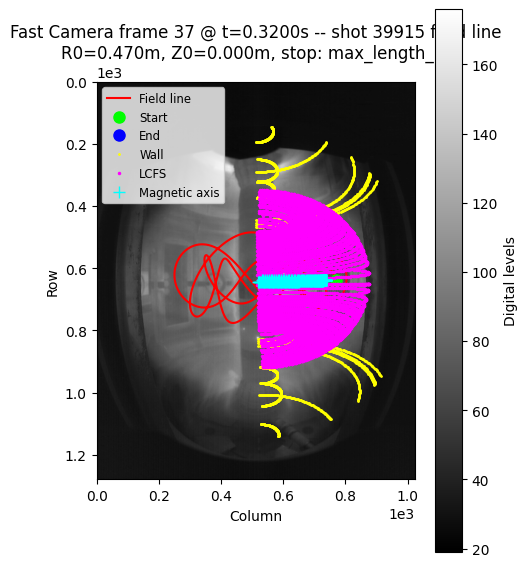

In [15]:
frame_idx_320 = int(np.argmin(np.abs(frame_times_ms - target_ms)))
fig, ax = vaft.omas.plot_camera_visible_image_field_line(
    ods, shot=39915, r0=R0, z0=Z0, phi0=0.0,
    frame_index=frame_idx_320, dphi_deg=0.5, max_length_m=10.0,
    direction="forward", use_wall_boundary=True,
    show_wall=True, show_lcfs=True, show_magnetic_axis=True,
)

## Tokamak-Physics Applications

The overlays above are more than a visual check -- they let you relate
directly-observed camera structure to the reconstructed magnetic geometry:

- **Relating visible structure to the equilibrium.** Overlaying the LCFS on a
  real frame lets you check whether any visible glow/structure sits inside or
  outside the last closed flux surface -- inside would suggest core plasma
  emission, outside would suggest limiter/wall interaction or reflected light.
- **Spatial reference against the vessel.** The projected wall outline gives a
  pixel-space reference frame tying camera features to real vessel structure
  (ports, tiles) independent of the equilibrium.
- **Field-line context (connection length intuition).** The traced-and-projected
  field line shows, for a chosen point in the plasma, where that magnetic
  surface actually sits in real 3D space and how far along it travels before
  intercepting the wall -- directly relevant to interpreting limiter shadow,
  strike-point-like features, or where energy/particles transported along that
  field line would deposit.

**Honest caveat for this specific sample**: shot 39915 in this frame range
corresponds to a low-current, early-phase plasma (`Ip ~ 77 kA`, established
while validating the field-line tracer against this same shot's real
`g039915.00319` equilibrium). Visible plasma emission may be faint or absent
in these particular frames -- this demo prioritizes reproducibility with
packaged sample data over a visually dramatic example. The methodology applies
unchanged to shots with stronger, more visible emission.

## Summary & Known Adaptations / Limitations

This notebook demonstrated, with real sample data and real output at every
step: loading and animating FAST-camera frames; the calibrated pinhole
camera model and its 3D-to-2D projection; equilibrium/vessel-geometry
overlay on real frames; and magnetic field-line tracing, both in
equilibrium space and projected into camera pixels.

**Adaptations from the original `VEST_Fast Camera_Diagnostics` notebook**:

- Wall/LCFS/flux-surface geometry comes from the ODS (`wall`/`equilibrium`
  IDSs), not the original notebook's `vest_wallgeo.mat`/pre-fit
  `Equilibrium_*.mat` flux-surface product.
- Flux surfaces are ODS psi-grid contours (`extract_flux_surface_contours`),
  not the original notebook's separately-fit 50-surface product -- only the
  LCFS (level 1.0) is guaranteed directly comparable.
- No SOL/vacuum field model beyond the LCFS for field-line tracing (`F(psi)`
  clipped to its boundary value there).
- The dense LCFS/wall point-cloud rendering (many toroidally-swept points
  scattered directly) is visually busier than a clean silhouette line --
  this matches the original notebook's own rendering approach, not a vaft
  regression.

**Other limitations**:

- Calibrated camera geometry (intrinsics + pose) exists for only three shots:
  34764, 39915, 47518.
- This notebook's camera sample data is a curated 66-frame valid interval
  (via `find_valid_frame_interval`), not the full raw numbered-frame sequence
  -- raw originals aren't archived for this shot.
- Wall crossing during field-line tracing is detected only at RK4 step
  resolution (no sub-step root-finding), so a traced endpoint sits slightly
  outside the wall rather than exactly on it.